# 04 — Near-optimality, route branches, values table, tiebreak

Fourth of four (spec §9, steps 4a–4d). Products: `near_optimality.tif` (**D11**, wall-to-wall
slack in raw cost units, **G10**), route branches (**D12**, **G9**) with the
`route_irreplaceable` flag, the per-branch values table on the Y2Y-wide column spec (**D13**,
**G11**) with the Carroll 2018 audit column (**D14**, H6-guarded), and the tie-break ranking.
Ends with `cc.finish(A)` — the completed run + `runs.csv` index.


In [1]:
# ---- Setup: find the project root, import the shared engines ----------------
# This notebook lives in analyses/northern_connectivity/, below the repo root where config.py
# and the corridor engine modules (corridors_prep / corridor_graph / corridors_core /
# corridors_ensemble) sit. Same bootstrap pattern as analyses/y2y/.
import sys, pathlib
_cands = [p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
          if (p / "config.py").exists()]
assert _cands, f"config.py not found above {pathlib.Path.cwd()} -- run this notebook from inside the repo"
ROOT = _cands[0]
sys.path.insert(0, str(ROOT))

import importlib
import config
import corridors_prep as cp
import corridor_graph as cg
import corridors_core as cc
import corridors_ensemble as ce
for _m in (config, cp, cg, cc, ce):
    importlib.reload(_m)

KEY = "north"


In [2]:
# ---- Re-attach to the run created by 02_calibrate_baseline ------------------
# One run spans notebooks 02-04: 02 created it via cc.start(); here cc.load() reads ONLY the run
# dir (run_config.json + the H7 copies), then the cached CWD + graph are re-derived -- the CWD
# stage is a cache HIT (seconds), the network rebuild is minutes. cwd_cutoff_abs was written into
# run_config.json by cc.set_cutoff in notebook 02, so nothing here depends on config.py.
RUN = "v2_run002"                       # <-- the run to continue

A = cc.load(config.RESULTS_DIR / "corridors_north" / RUN)
cc.resistance(A)
cc.cost_distances(A)                    # cache HIT
cc.corridor_network(A, verbose=False)
A


Northern BC + Yukon: routing grid 2809x5767 @ 300 m = 9,696,945 routable cells (872,725 km²)
  cropped from the 4285x5767 warped window (66% of its cells) = anchors + 100 km routing buffer
  merged node: IPCA · Peel Watershed - SMA/WA absorbs Teetł’it Gwinjik (Peel River) (4,147 km² nested)
  merged node: PA · Nj ‘Iinlii” Jjik (Fishing Branch) Habitat Protection Area absorbs Fishing Branch Wilderness Preserve (5,355 km² nested)
  merged node: PA · Neah Conservancy absorbs Ne'ah – Horseranch Range Deadwood Lake Protected Area (2,312 km² nested)
nodes: 42 (10 IPCAs + 32 existing PAs >= 200 km²)  [min node size 25 km² = 278 cells @ 300 m]
  dropped 2 IPCA(s) below 25 km² in region: Wëdzey Nähuzhi (Matson Uplands), Łuk Tthe K’ät (Scottie Creek Wetlands)
  node land: 242,540 km² (excluded from the corridor)
D16 parts: 42 names -> 48 seed parts -> 42 routing units  (4 multipart: Dene Kʼéh Kusān 3p/link_locked; Liard River Corridor Park 3p/link_locked; Nahanni National Park Reserve Of Canada 

<corridors v2_run002 | 42 nodes | 2809x5767 | 58 edges | corridor 33,041 km²>

## Step 0b — re-profile the corridor under the curated EFG block (added 2026-09-09, M5.16)

The EFG block was R0-curated 40 → 20 features (y2y M2.11) and Ethan adopted it for this analysis. `corridor_profile.csv` / the audit figures / gate G5 were computed on the 40-class block in notebook 02; this step regenerates them on the curated block (the manifest now lists the 20 layers). G5 reports the EFG and macrorefugia axes instead of asserting on them. Harmless on a fresh run. Also runs gate G15 (D19, 2026-09-11) so `centrality_compare.csv` and the `centrality_cf` / `centrality_sp` columns land without re-running notebook 02. And the D21 adjacency graph (step 2c, G17), so `allocation.tif` / `adjacency_*.csv` / `adjacency_map.png` land on the loaded run too.


corridor segments: 71 components merged by location into 10 clusters (100% of corridor area — all of it)
  multi-part clusters: 1 = 7 components; 2 = 11 components; 3 = 4 components; 4 = 15 components; 5 = 4 components; 6 = 6 components; 8 = 14 components; 9 = 6 components; 10 = 3 components
  building 8 continuous + 20 EFG stacks on the 1000 m AUDIT grid…
  crossing masks 300 m -> 1 km for profiling:
  OK  audit grid: 1. IPCA · Peel Watershed - SMA/WA (+1) 3,996 km² @300 m -> 4,139 km² @1 km (+3.6%)
  OK  audit grid: 2. IPCA · Peel Watershed - SMA/WA (+1) 2,830 km² @300 m -> 2,871 km² @1 km (+1.5%)
  OK  audit grid: 3. IPCA · Dene Kʼéh Kusān ↔ PA · Liard 2,079 km² @300 m -> 2,109 km² @1 km (+1.4%)
  OK  audit grid: 4. IPCA · Dene Kʼéh Kusān ↔ IPCA · T’a 8,743 km² @300 m -> 8,825 km² @1 km (+0.9%)
  OK  audit grid: 5. PA · Graham Laurier Park ↔ PA · Klu 3,130 km² @300 m -> 3,280 km² @1 km (+4.8%)
  OK  audit grid: 6. IPCA · Dene Kʼéh Kusān ↔ IPCA · Wəd 2,880 km² @300 m -> 2,960 km² @1 

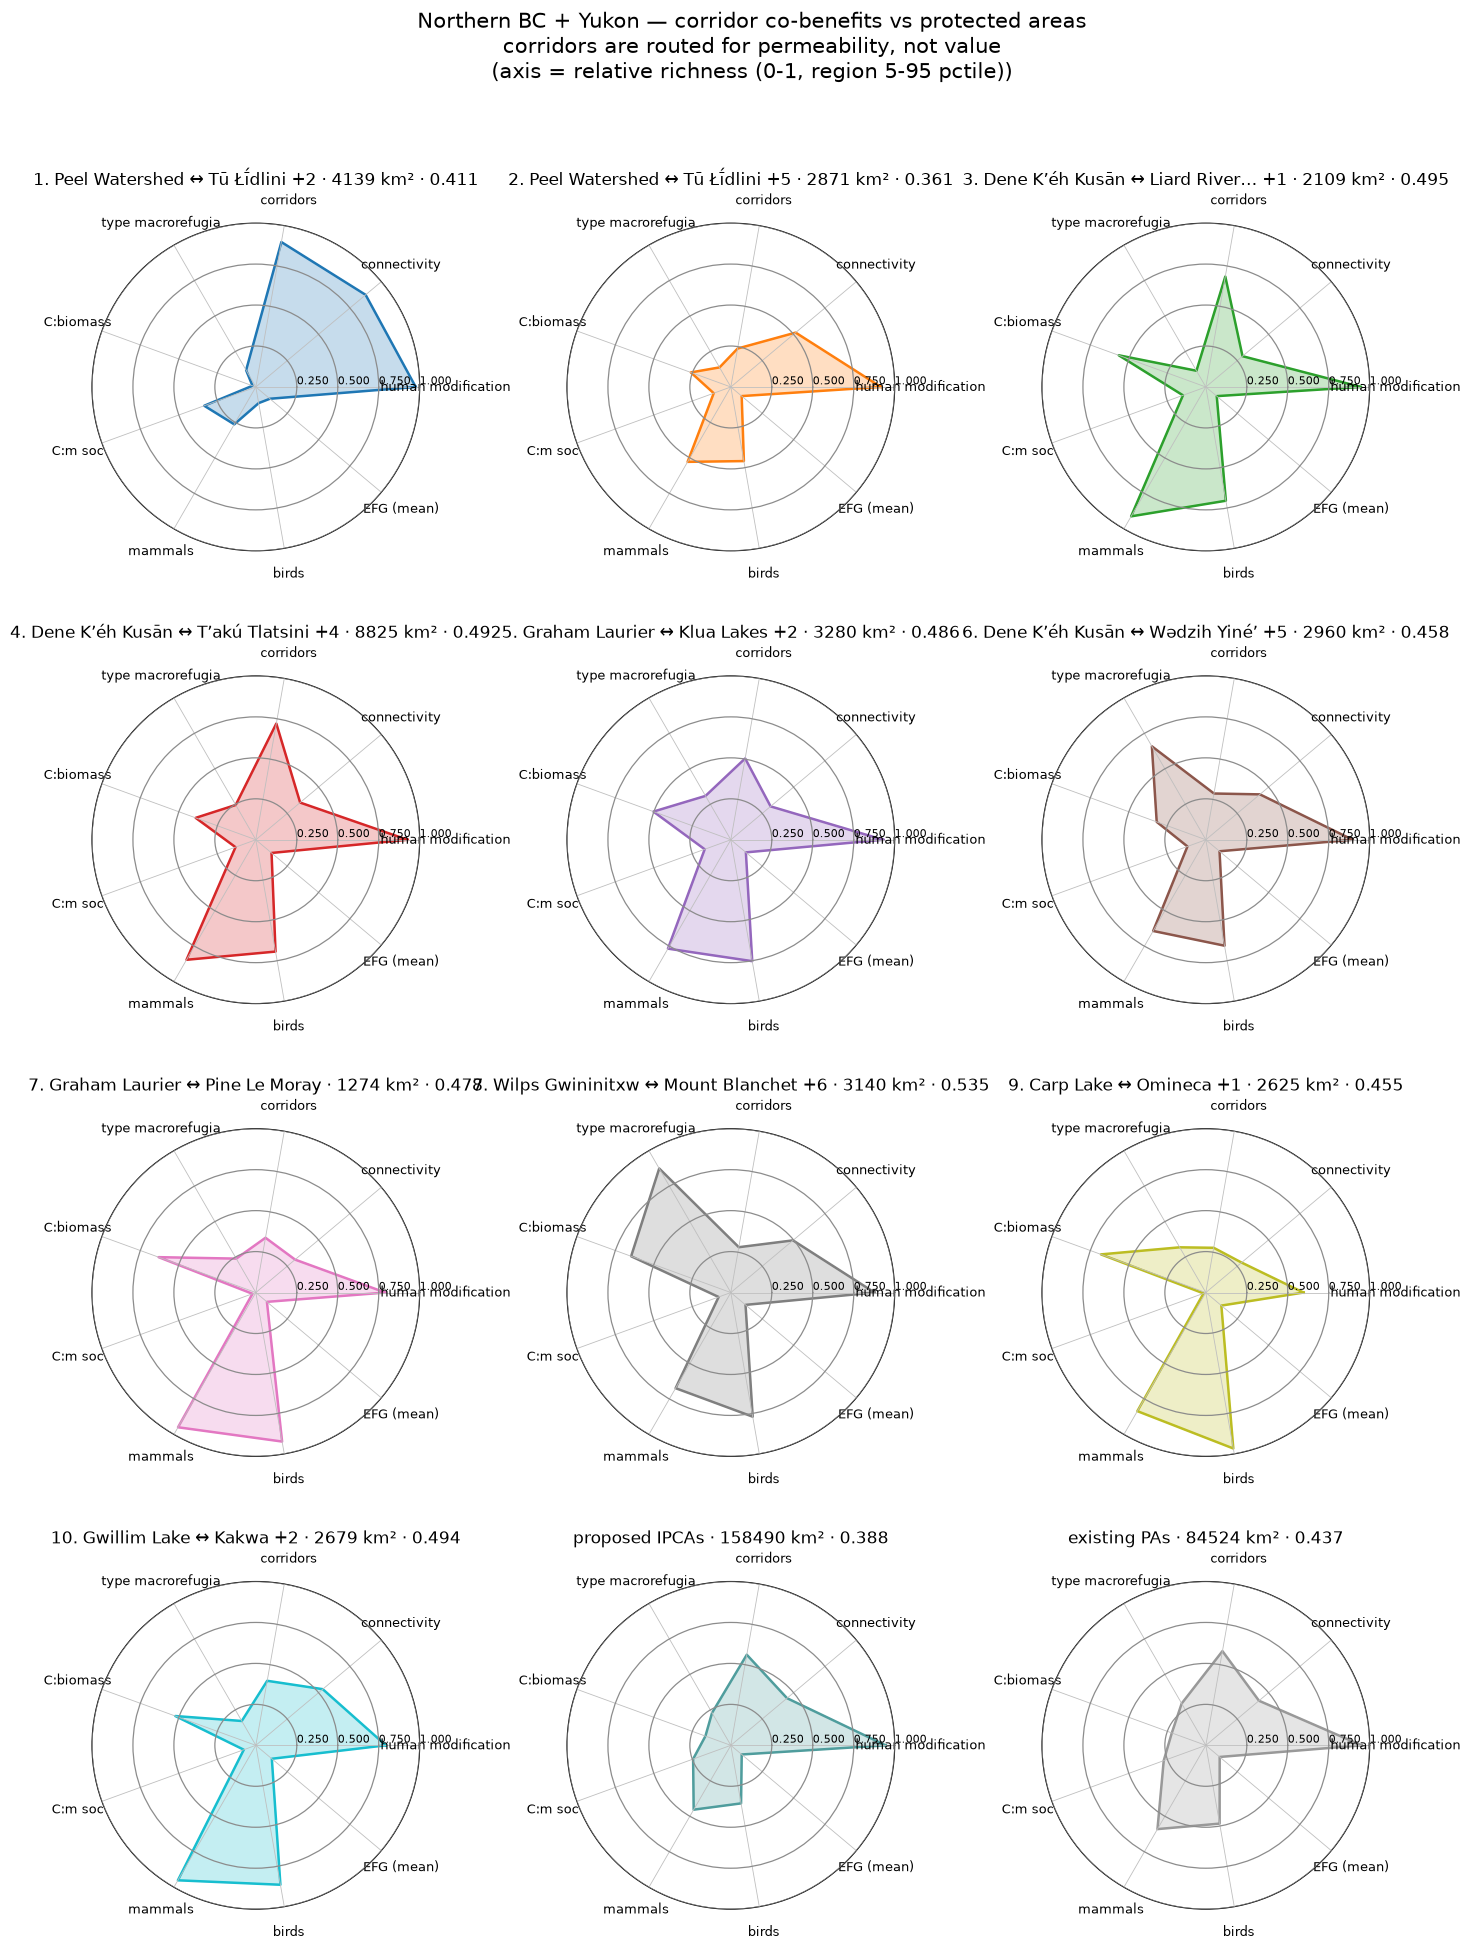

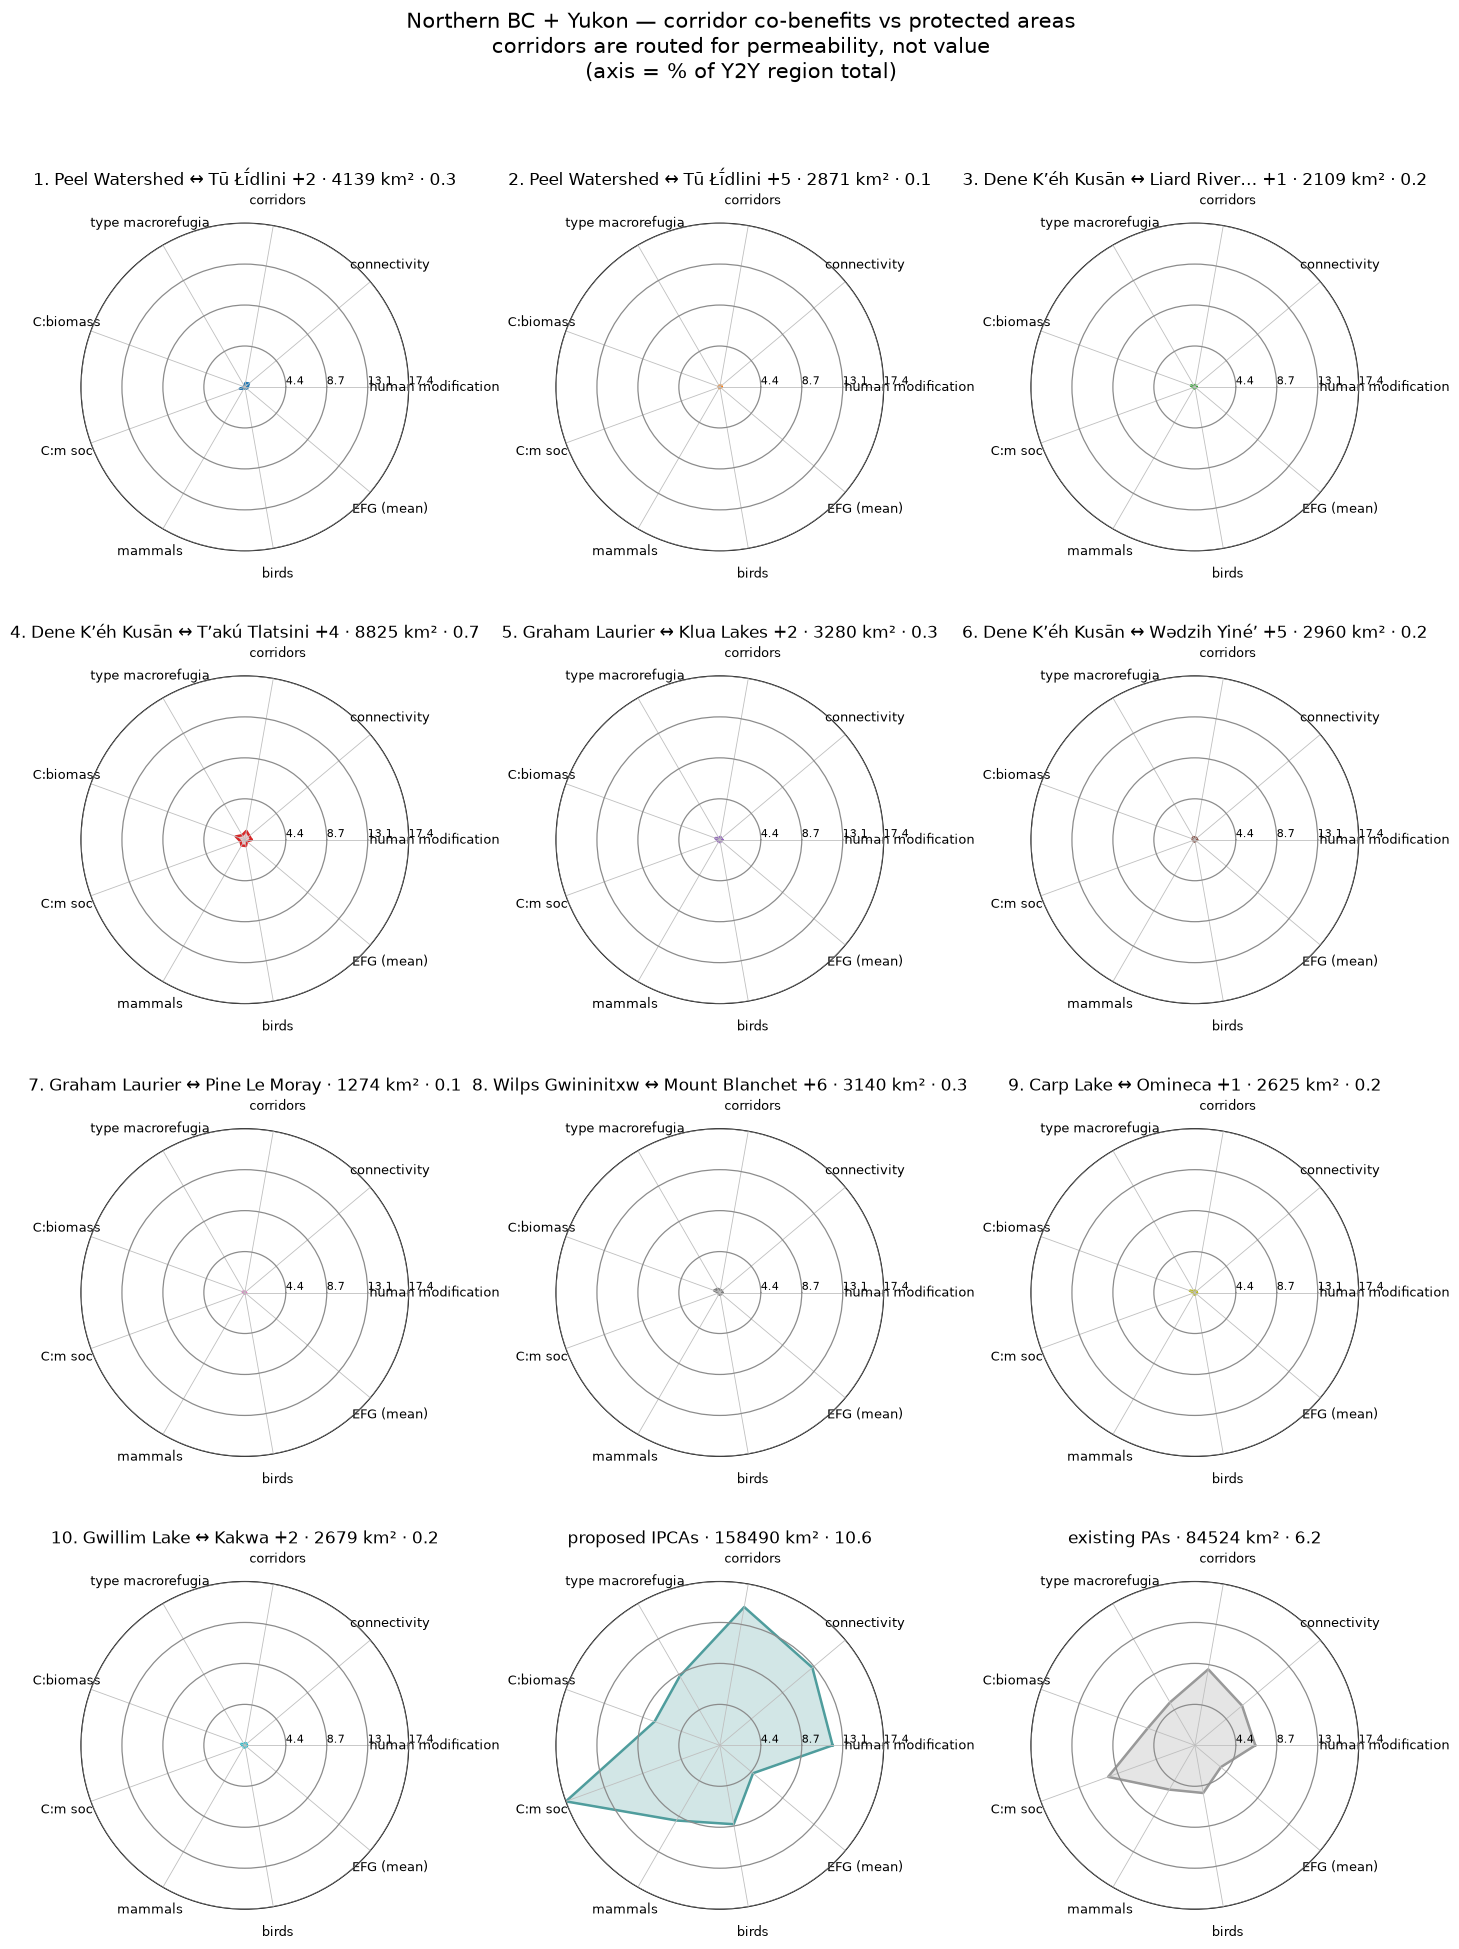

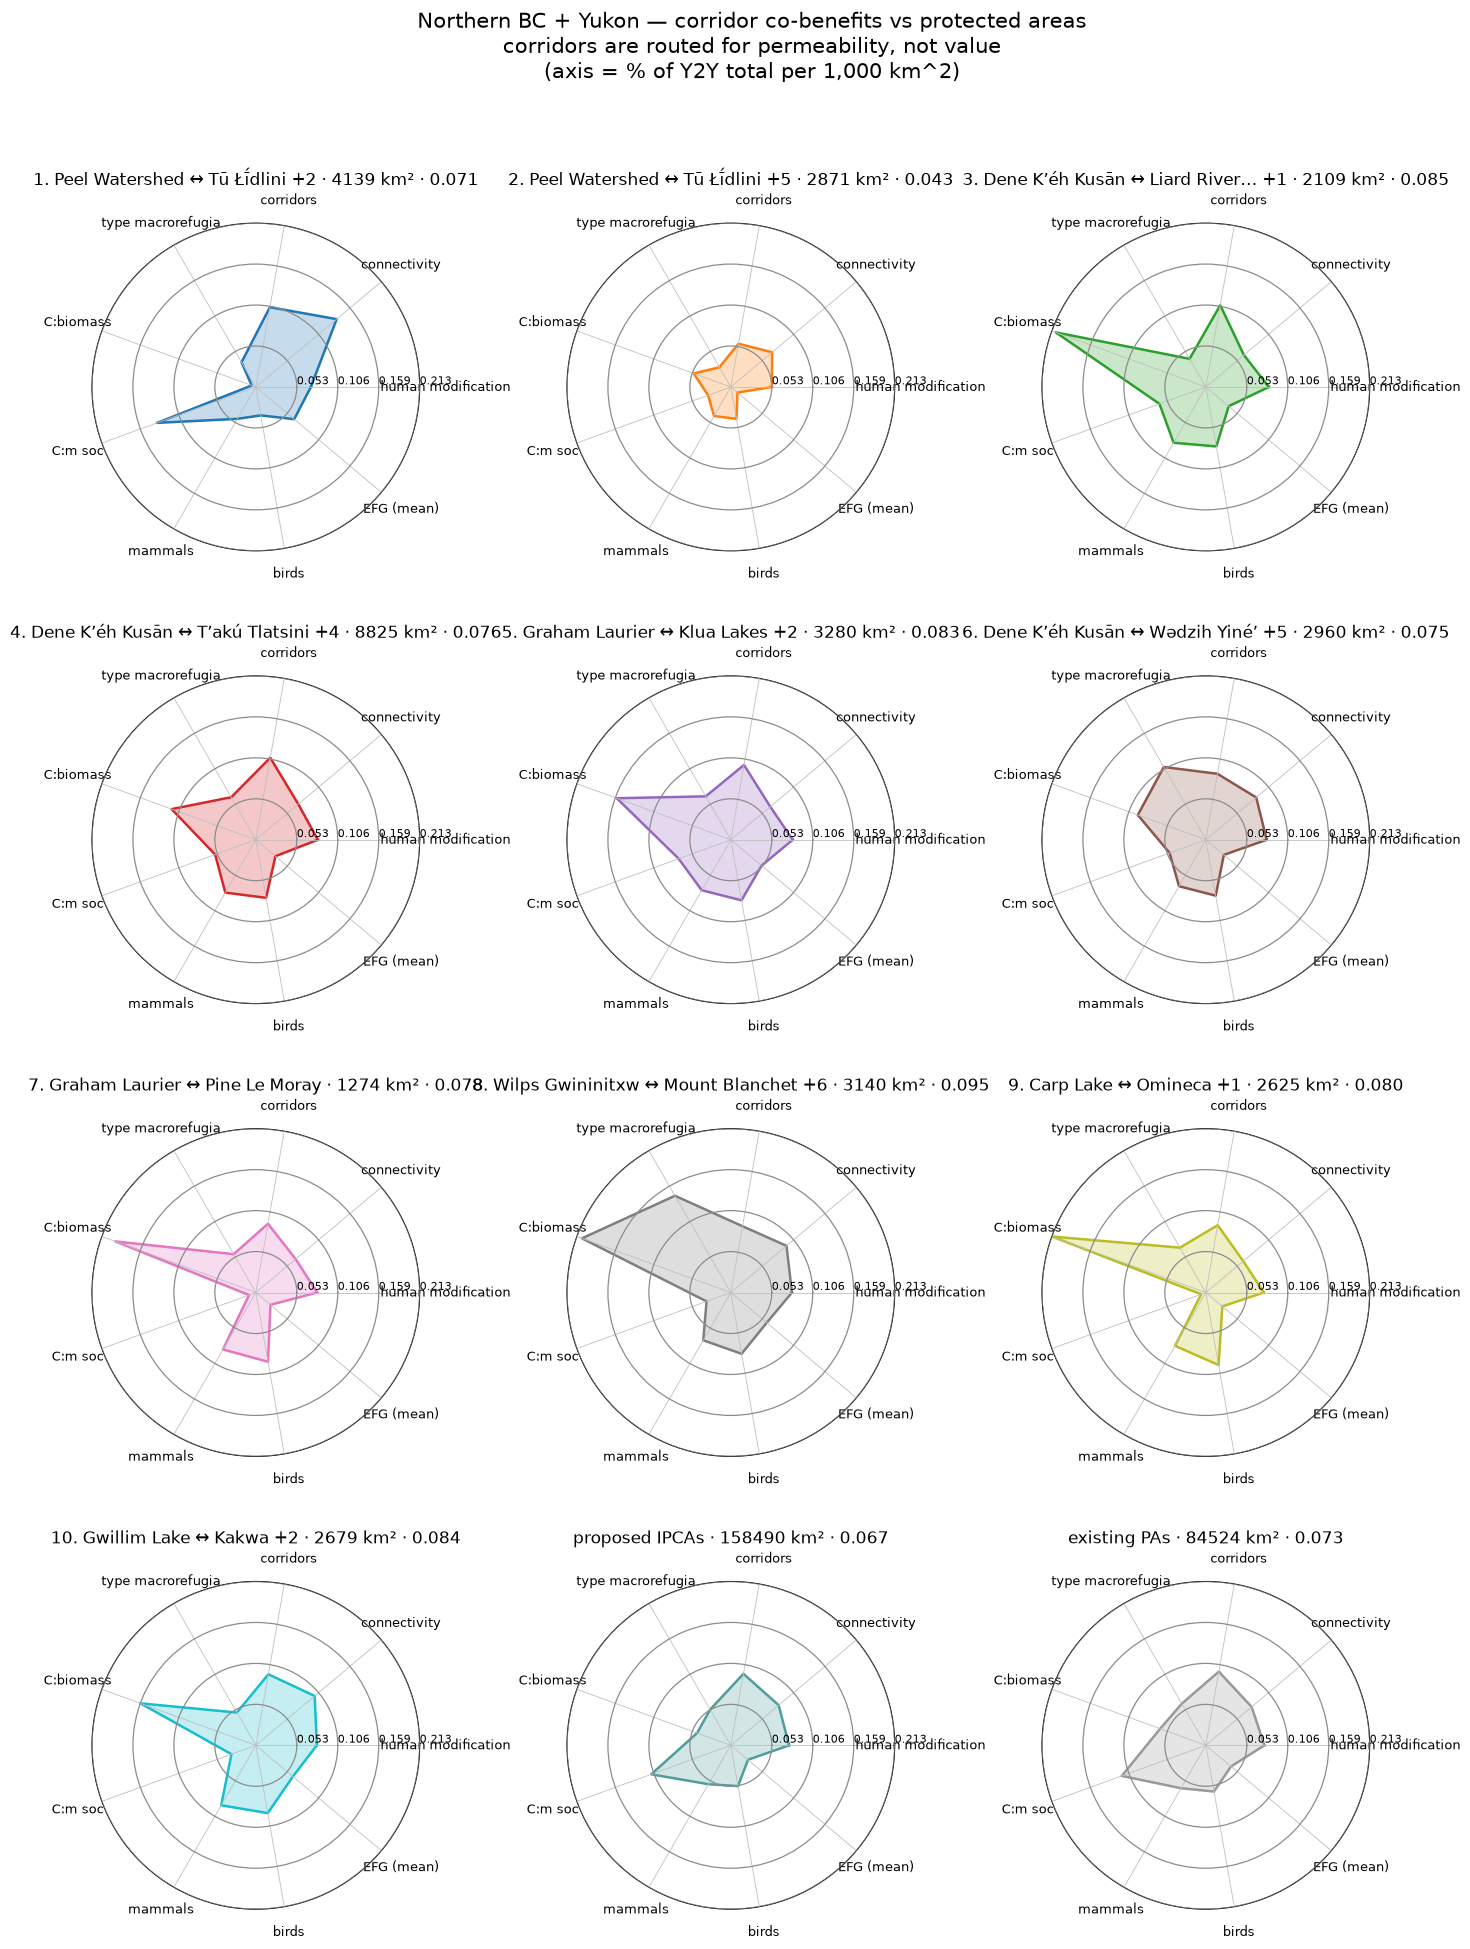

  wrote corridor_profile.csv
  proposed IPCAs   max |Δrichness| over 7 unchanged axes = 0.0020
    reported, not asserted (climate type macrorefugia: feature redefined after v1 froze): v1 0.504 -> v2 0.229
    reported, not asserted (EFG (mean): feature redefined after v1 froze): v1 0.052 -> v2 0.087
  existing PAs     max |Δrichness| over 7 unchanged axes = 0.0020
    reported, not asserted (climate type macrorefugia: feature redefined after v1 froze): v1 0.555 -> v2 0.295
    reported, not asserted (EFG (mean): feature redefined after v1 froze): v1 0.073 -> v2 0.110
G5 OK — audit path unchanged on every axis with an unchanged feature definition


In [3]:
cc.corridor_profile(A, n_groups=10)      # regenerates corridor_profile.csv + audit figures
cc.gate_g15(A)                           # D19 (2026-09-11): centrality_compare.csv on the loaded run
cc.adjacency_graph(A)                    # D21 (2026-09-11): neighbour universe + G17 on the loaded run
cc.gate_g5(A)


## Step 4a · Near-optimality surface (**D11**) · **gate G10**

`min_e slack_e` in raw cost units on every routable cell — the band IS the closed-form
near-optimal set and slack its continuous degree. Tiers are percentiles of slack over the union
band at 2× cutoff (pre-registered in config). Zero-cost adjacency edges contribute nothing.


In [4]:
cc.near_optimality(A)


G10 OK: max residual on baseline least-cost paths = 6.1e-05 cost units
near-optimality surface over 9,696,945 routable cells (tier domain = union band at 2x cutoff, 792,176 cells)
  robust_core  (slack <=            1 = p10):     7,131 km²
  frequent     (slack <=            7 = p30):    14,260 km²
  occasional   (rest of routable):          851,334 km²
  wrote near_optimality.tif, near_opt_owner.tif, near_optimality_class.tif (+ owner legend)


<corridors v2_run002 | 42 nodes | 2809x5767 | 58 edges | corridor 33,041 km² | 10 segments>

## Step 4b · Route branches (**D12**) · **gate G9**

Per edge (locked intra-name edges included), 8-connected band components at
`branch_mult × cutoff`, formed BEFORE node subtraction (G9 asserts each touches both
endpoints), then node land removed and slivers < `branch_min_km2` dropped (count reported).
`n_branches == 1` ⇒ route-irreplaceable — reported alongside, never merged with, the D7
edge-irreplaceable flag.


In [5]:
cc.route_branches(A)


route branches @ 0.5x cutoff (7): 41 branches over 45 edges | 35 ROUTE-irreplaceable edges, 3 with alternatives | 11 slivers < 10 km² dropped
  route-irreplaceable (D12, within-link) vs edge-irreplaceable (D7, no alternative link) are DIFFERENT senses -- always reported together, never merged
  wrote branches.tif, branches.gpkg, branches.csv


<corridors v2_run002 | 42 nodes | 2809x5767 | 58 edges | corridor 33,041 km² | 10 segments>

## Step 4c · Per-branch values table (**D13/D14**) · **gate G11**

Masks cross 300 m → 1 km (`_to_audit`, ≥ 0.5 areal fraction); columns are imported from
`results_core` (RAW_SPEC / `mask_profile`) — same spec as the Y2Y-wide alternatives tables.
Row unit is edge × route branch, NOT a solution cluster (the caption ships in
`alternatives_branches.meta.json`). `carroll2018_pctl` is audit-only (D14); if the layer is
absent the gap is logged, not fatal (H6).


In [6]:
cc.alternatives_table(A)


G11 audit-crossing check (300 m -> 1 km):
  OK  E000_002_1                  2,743 km² ->    2,743 km²  (+0.0%)
  OK  E001_023_1                     44 km² ->       44 km²  (+0.0%)
  OK  E001_023_2                     30 km² ->       30 km²  (+0.0%)
  OK  E001_028_1                  1,098 km² ->    1,098 km²  (+0.0%)
  OK  E001_036_1                    138 km² ->      138 km²  (+0.0%)
  OK  E002_012_1                    791 km² ->      791 km²  (+0.0%)
  OK  E003_026_1                    654 km² ->      654 km²  (+0.0%)
  OK  E003_036_1                    262 km² ->      262 km²  (+0.0%)
  OK  E005_025_1                  1,093 km² ->    1,093 km²  (+0.0%)
  OK  E005_038_1                    148 km² ->      148 km²  (+0.0%)
  OK  E005_039_1                    238 km² ->      238 km²  (+0.0%)
  OK  E005_040_1                    233 km² ->      233 km²  (+0.0%)
  OK  E006_016_1                     26 km² ->       26 km²  (+0.0%)
  OK  E007_008_2                    152 km² ->      152 km²  

<corridors v2_run002 | 42 nodes | 2809x5767 | 58 edges | corridor 33,041 km² | 10 segments>

## Step 4d · Tie-break report (Phase 8.3, small)

Ranking only — no automated "recommended" flag; the recommendation is a human read of the table.


In [7]:
cc.tiebreak(A)


tiebreak.csv: 6 branch rows over 3 edges with alternatives (ranking only; recommendation is a human read)


<corridors v2_run002 | 42 nodes | 2809x5767 | 58 edges | corridor 33,041 km² | 10 segments>

## Step 2b · The squeezed class — counterfactual band (**D17**) · **gate G13**

H8 closed 2026-09-03: `squeezed` is defined as the real band's NEW-land area over the band the
same link gets on a surface with every cost class ≥ 10 set to 1 (all barriers relaxed) — the
'natural width' counterfactual, banded at the same `cwd_cutoff_abs`. Ratio < `squeeze_ratio`
(0.5) ⇒ squeezed. One extra CWD set on the relaxed surface (cached under `cwd_cache/<sha>_cf`;
expect roughly the notebook-02 CWD runtime on first execution, seconds afterwards). G13 asserts
the counterfactual band is never narrower than the real one. Writes
`bands_counterfactual.gpkg` (the M3 outline) and the D17 columns into the edge table, which
`cc.finish` carries into `corridor_edges.csv` / `criticality.csv`. Supersedes the analytic
screening index (M4.6) as the CLASS definition; that index stays as a diagnostic column.


In [8]:
cc.counterfactual_squeeze(A)


D17 counterfactual: 1,146,616 cells (11.8% of routable) with cost >= 10 set to 1; banding every edge at cutoff 13.623
  counterfactual CWD from 48 seed parts (cache HIT: 8487b2284c1a19a3_cf)
  G13 note: 6 link(s) have a NARROWER counterfactual (shorter route and/or a real-surface near-tie broken by relaxation) -- reported, not squeezed: E003_036 w 38.2->33.5 km, L 31->29 km, E007_008 w 17.6->16.4 km, L 19->16 km, E009_015 w 18.6->18.2 km, L 25->26 km, E009_038 w 11.1->10.7 km, L 40->40 km, E023_028 w 38.5->17.0 km, L 135->137 km, L032_033 w 16.0->15.5 km, L 10->11 km
  G13 OK: counterfactual optimum <= real optimum on all 58 banded edges (relaxation invariant); 37 edges eligible for the width ratio
  SQUEEZED (ratio < 0.5): 8 links -- Carp Lake↔Pine Le Moray 0.23, Gwillim Lake↔Monkman 0.32, Gwillim Lake↔Kakwa 0.37, Graham Laurier↔Pine Le Moray 0.40, Gwillim Lake↔Pine Le Moray 0.41, Mount Blanchet↔Sustut 0.41, Wilps Gwininit…↔Mount Blanchet 0.41, Wilps Gwininit…↔Sustut 0.49
  wrote band

<corridors v2_run002 | 42 nodes | 2809x5767 | 58 edges | corridor 33,041 km² | 10 segments>

## Finish — complete the run + the analysis-level index


In [9]:
cc.finish(A)
cc.runs(KEY)


  wrote output_data/corridors_north/v2_run002/corridors.tif
  wrote output_data/corridors_north/v2_run002/resistance.tif
  wrote output_data/corridors_north/v2_run002/corridors.gpkg
  wrote output_data/corridors_north/v2_run002/corridor_edges.csv
  wrote output_data/corridors_north/v2_run002/criticality.csv
  wrote output_data/corridors_north/v2_run002/corridor_edges.gpkg
  wrote output_data/corridors_north/v2_run002/corridor_summary.json
  wrote output_data/corridors_north/runs.csv


,run_id,label,git,done,corridor_km2,n_edges,n_groups
0,v2_run002,v2 baseline,9eab9bab,True,33041,58,1
